# Evaluating Logistic Regression Predictions - suv_data.csv

## 0) Pre-Installations 

In [1]:
import os

# Change the current working directory
os.chdir('~/Desktop/DE_coding_portfolio/4')

In [2]:
# Import Necessary Libraries
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy import stats
from scipy.stats import multivariate_normal, bernoulli, beta, norm
from scipy.stats import ks_2samp
from scipy.special import expit as logistic_sigmoid
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import cross_val_score
from sklearn.metrics import balanced_accuracy_score, brier_score_loss, accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.model_selection import KFold

# Set display option to avoid scientific notation in pandas, show up to 5 decimal points
pd.set_option('display.float_format', lambda x: '%.5f' % x)
# and numpy
np.set_printoptions(suppress=True, precision=5)

In [3]:
# Load the dataset
df = pd.read_csv('suv_data.csv')

# Display the first few rows of the dataset
print("Dataset Preview:")
print(df.head())

Dataset Preview:
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


## 1) Data Cleaning & Exploration

#### i. drop incomplete records

In [4]:
# Drop incomplete records
df = df.dropna()

# Verify dataset shape after dropping incomplete records
print(f"Dataset shape after dropping incomplete records: {df.shape}")

Dataset shape after dropping incomplete records: (400, 5)


#### ii. Create a dummy variable for Purchased

In [5]:
# SUV purchase flag
purchased_binary = df['Purchased'].astype(int)

# Verify the creation of the binary variable
print("First 10 values of the 'Purchased' binary column:")
print(purchased_binary.head(10))

First 10 values of the 'Purchased' binary column:
0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    1
8    0
9    0
Name: Purchased, dtype: int64


#### iii. One-hot encode: Gender

In [6]:
# One-hot encode gender
gender_one_hot = pd.get_dummies(df['Gender'], drop_first=True)  # Male -> 1, Female -> 0
gender_one_hot = gender_one_hot.rename(columns={"Male": "Gender_Male"}).astype(int)

# Verify one-hot encoding
print("Gender One-Hot Encoding Preview:")
print(gender_one_hot.head())

Gender One-Hot Encoding Preview:
   Gender_Male
0            1
1            1
2            0
3            0
4            1


#### iv. Binary Variable indicating high income

In [7]:
# Define a high-income threshold (e.g., 70,000)
high_income_binary = (df['EstimatedSalary'] > 70000).astype(int).rename("High_Income")

# Verify the binary variable
print("High Income Binary Variable Preview:")
print(high_income_binary.head())

High Income Binary Variable Preview:
0    0
1    0
2    0
3    0
4    1
Name: High_Income, dtype: int64


#### v. One-hot encode: Age Group 

In [8]:
# Binning age into groups
age_bins = [0, 25, 35, 45, 55, 100]
age_labels = ["<25", "25-35", "35-45", "45-55", "55+"]
age_group = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

# Binary encode age group and convert boolean to integers
age_binary = pd.get_dummies(age_group, prefix="Age_Group").astype(int)

# Verify the binary encoding
print("Age Group Binary Encoding Preview:")
print(age_binary.head())

Age Group Binary Encoding Preview:
   Age_Group_<25  Age_Group_25-35  Age_Group_35-45  Age_Group_45-55  \
0              1                0                0                0   
1              0                0                1                0   
2              0                1                0                0   
3              0                1                0                0   
4              1                0                0                0   

   Age_Group_55+  
0              0  
1              0  
2              0  
3              0  
4              0  


- The <25 category is not shown in the one-hot encoding because the drop_first=True parameter was used. This drops the first category to avoid the dummy variable trap in statistical models, where one category serves as the reference point.

#### vi. Concatenate cleaned varaibles into a new dataframe X

In [9]:
# Combine the cleaned variables, including binary-encoded age groups
X = pd.concat([gender_one_hot, high_income_binary, age_binary], axis=1)

# Verify the combined dataframe
print("Cleaned DataFrame Preview:")
print(X.head())

Cleaned DataFrame Preview:
   Gender_Male  High_Income  Age_Group_<25  Age_Group_25-35  Age_Group_35-45  \
0            1            0              1                0                0   
1            1            0              0                0                1   
2            0            0              0                1                0   
3            0            0              0                1                0   
4            1            1              1                0                0   

   Age_Group_45-55  Age_Group_55+  
0                0              0  
1                0              0  
2                0              0  
3                0              0  
4                0              0  


#### vii. Calculate the correlation matrix 

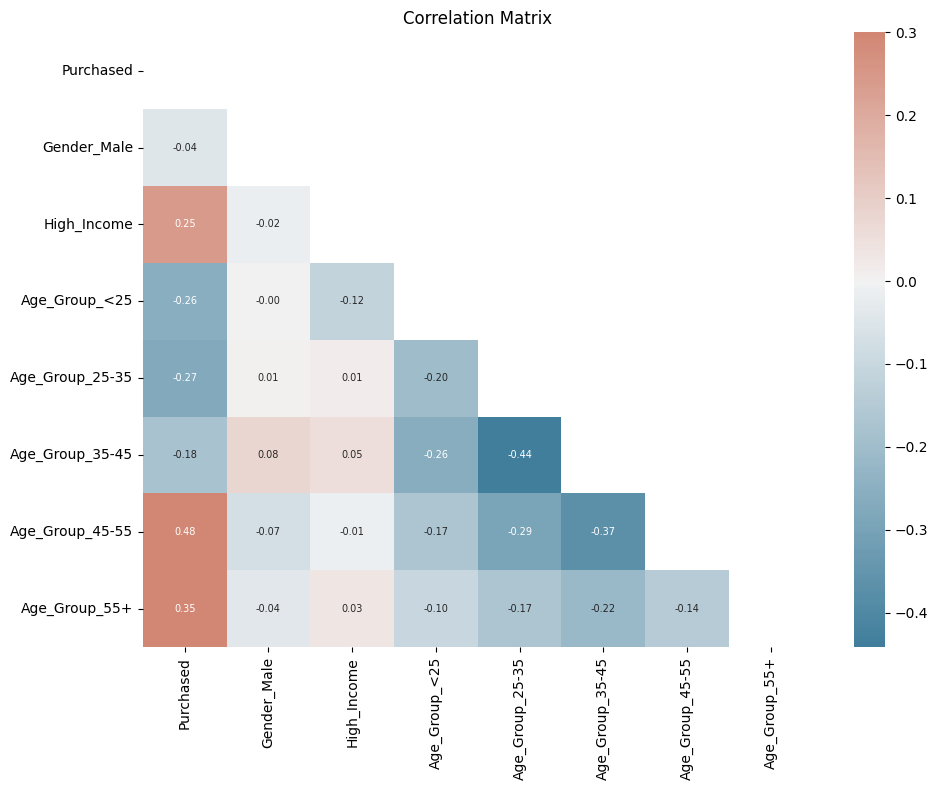

In [10]:
# Add 'Purchased' binary column to create a combined DataFrame
X['Purchased'] = purchased_binary
YX = X[['Purchased'] + [c for c in X.columns if c != 'Purchased']]  # Ensure 'Purchased' is the first column

# Calculate the Correlation Matrix
corr = YX.corr()

# Plotting the Correlation Matrix
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0, annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### Key Insights from the Correlation Matrix

1. **High Income and SUV Purchase**:
   - A moderate positive correlation (0.25) exists between High_Income and Purchased, suggesting that individuals with higher income are more likely to purchase an SUV.

2. **Age Groups and SUV Purchase**:
   - Age_Group_45-55 has the strongest positive correlation (0.48) with Purchased, indicating that individuals in this age group are most likely to purchase an SUV.
   - Age_Group_25-35 and Age_Group_35-45 show weak negative correlations with Purchased (-0.27 and -0.18, respectively), implying these groups are less likely to purchase an SUV.

3. **Gender and SUV Purchase**:
   - Gender_Male has a correlation (-0.04) with Purchased, suggesting no significant relationship between gender and SUV purchase likelihood.

4. **Interrelations Among predictors**:
   - Strong negative correlations between certain age groups (e.g., Age_Group_35-45 and Age_Group_45-55 with -0.44) reflect the exclusivity of these categorical bins.
   - High_Income has minimal correlation with age groups, indicating income is relatively independent of age in this dataset.

## 2) Model Assessment and Selection

#### i. Set up the full design matrix

In [11]:
# Design matrix including all covariates
X = pd.concat([gender_one_hot, high_income_binary, age_binary], axis=1)

# Add a constant for the intercept (required for statsmodels)
X_const = sm.add_constant(X)

# Get the full dataset together, with the outcome variable as the first column
purchased_binary.name = "Purchased"  # Ensure consistent column name
YX_const = pd.concat([purchased_binary, X_const], axis=1)

# Verify the design matrix
print("Design matrix (first 5 rows):")
print(YX_const.head())

Design matrix (first 5 rows):
   Purchased   const  Gender_Male  High_Income  Age_Group_<25  \
0          0 1.00000            1            0              1   
1          0 1.00000            1            0              0   
2          0 1.00000            0            0              0   
3          0 1.00000            0            0              0   
4          0 1.00000            1            1              1   

   Age_Group_25-35  Age_Group_35-45  Age_Group_45-55  Age_Group_55+  
0                0                0                0              0  
1                0                1                0              0  
2                1                0                0              0  
3                1                0                0              0  
4                0                0                0              0  


#### ii. Create a validation set (75%) and test set (25%)

In [12]:
# Split data into validation and test (75:25)
YX_const_val, YX_const_test = train_test_split(YX_const, test_size=0.25, random_state=42)

# Verify the split
print(f"Validation Set Size: {YX_const_val.shape[0]}, Test Set Size: {YX_const_test.shape[0]}")

Validation Set Size: 300, Test Set Size: 100


#### iii. Define candidate models

In [13]:
# Define predictors for each model variant
predictors = {
    'a': ['const'],  # Homogeneous probability model (only intercept)
    'b': ['const', 'Gender_Male', 'High_Income'],  # Selected covariates
    'c': ['const', 'Gender_Male', 'High_Income', 'Age_Group_<25', 'Age_Group_25-35', 'Age_Group_35-45', 'Age_Group_45-55']  # Drop 'Age_Group_55+'
}

# Verify predictors
print("Candidate Models:")
for key, cols in predictors.items():
    print(f"Model {key}: {cols}")

Candidate Models:
Model a: ['const']
Model b: ['const', 'Gender_Male', 'High_Income']
Model c: ['const', 'Gender_Male', 'High_Income', 'Age_Group_<25', 'Age_Group_25-35', 'Age_Group_35-45', 'Age_Group_45-55']


#### iv. Model Comparison using cross-validation

In [14]:
# Ensure all columns are numeric, including converting booleans to integers
YX_const_val = YX_const_val.astype({col: int for col in YX_const_val.select_dtypes(include='bool').columns})

# Target variable
y = YX_const_val['Purchased']

# Define K for cross-validation
K = 5

# Set up KFold cross-validation
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Initialize a dictionary to store Brier scores
brier_scores = {key: [] for key in predictors}

for key, cols in predictors.items():
    print(f"\nEvaluating Model {key}...")

    for train_index, test_index in kf.split(YX_const_val):
        # Split into train and test folds
        X_train, X_test = YX_const_val.iloc[train_index][cols], YX_const_val.iloc[test_index][cols]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Verify matrix rank
        if np.linalg.matrix_rank(X_train.values) < X_train.shape[1]:
            print(f"Warning: X_train is not full rank for Model {key}. Dropping redundant columns.")
            X_train = X_train.loc[:, ~X_train.columns.duplicated()]
            X_test = X_test.loc[:, X_train.columns]

        # Fit the logistic regression model
        model = sm.Logit(y_train, X_train).fit_regularized(disp=False, alpha=1.0)

        # Predict probabilities
        y_pred_prob = model.predict(X_test)

        # Calculate Brier score
        brier_score = brier_score_loss(y_test, y_pred_prob)
        brier_scores[key].append(brier_score)

    # Print the average Brier score for the model
    average_brier_score = np.mean(brier_scores[key])
    print(f"Model {key}: Average Brier Score = {average_brier_score:.4f}")

# Create a DataFrame to summarize results
results = [{'Model': key, 'Average Brier Score': np.mean(scores)} for key, scores in brier_scores.items()]
results_df = pd.DataFrame(results).sort_values(by="Average Brier Score")

# Display results
print("\nModel Comparison Results:")
print(results_df)


Evaluating Model a...
Model a: Average Brier Score = 0.2303

Evaluating Model b...
Model b: Average Brier Score = 0.2244

Evaluating Model c...
Model c: Average Brier Score = 0.1417

Model Comparison Results:
  Model  Average Brier Score
2     c              0.14172
1     b              0.22439
0     a              0.23034


### What Does the Brier Score Imply?

The Brier score measures the accuracy of probabilistic predictions. It calculates the mean squared difference between the predicted probabilities and the actual binary outcomes (0 or 1). 

- **Range**: The score ranges from 0 to 1.
  - **0**: Perfect predictions (all probabilities align with actual outcomes).
  - **1**: Worst possible predictions (completely wrong probabilities).
- **Lower scores are better**, as they indicate more accurate probabilistic predictions.

### Interpretation of Results

1. **Model Performance**:
   - **Model C** performed the best, achieving the lowest average Brier score. This indicates that incorporating all available covariates, including age groups, improves the model's ability to predict SUV purchases accurately.
   - **Model B** follows with an average Brier score, suggesting that while it performs better than the baseline Model A, it misses the additional predictive power provided by the age group features.
   - **Model A** performed the worst with an average Brier score, as expected. This model only uses a single intercept and doesn’t take any covariates into account, making it the least informative.

2. **Conclusion**:
   - **Model C** is the best choice for predictive performance.
   - This aligns with the findings of previous logistic regression model which showed Heterogenous model is a better model to evaluate. 
   - Moving forward, we’ll re-fit Model C using the entire validation set to further refine the model and analyze its parameters.

#### v. Re-fit the selected model

In [15]:
# Select Model C for re-fitting
selected_model = 'c'

# Extract the predictors for Model C
X_selected = YX_const_val[predictors[selected_model]]
y_selected = YX_const_val['Purchased']



Step 1: Check Multicolinearity

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Drop the intercept for VIF calculation
X_for_vif = X_selected.drop(columns=['const'], errors='ignore')

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_for_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_for_vif.values, i) for i in range(X_for_vif.shape[1])]

print("Variance Inflation Factor (VIF):")
print(vif_data)

Variance Inflation Factor (VIF):
           Feature     VIF
0      Gender_Male 1.91676
1      High_Income 1.88578
2    Age_Group_<25 1.14198
3  Age_Group_25-35 1.42615
4  Age_Group_35-45 1.89855
5  Age_Group_45-55 1.29751


For all predictors VIF < 5, hence there is no convergence issue found.

In [17]:
# Fit the logistic regression model using the entire validation set
final_model = sm.Logit(y_train, X_train).fit_regularized(disp=False, alpha=1.0)

# Print the summary of the final model
print("Summary of the Re-fitted Model:")
print(final_model.summary())

Summary of the Re-fitted Model:
                           Logit Regression Results                           
Dep. Variable:              Purchased   No. Observations:                  240
Model:                          Logit   Df Residuals:                      235
Method:                           MLE   Df Model:                            4
Date:                Fri, 06 Dec 2024   Pseudo R-squ.:                  0.3735
Time:                        14:20:55   Log-Likelihood:                -98.809
converged:                       True   LL-Null:                       -157.72
Covariance Type:            nonrobust   LLR p-value:                 1.563e-24
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.4991      0.319      1.567      0.117      -0.125       1.123
Gender_Male              0        nan        nan        nan         nan         nan


1. **R-squared (0.3735)**:
- This indicates the model explains 37.35% of the variability in the SUV purchase.

2. **Coefficients**:
- Intercept (const): positive but not statistically significant (p-value = 0.117)
- High_income (1.6783): Significant (p-value <0.001), proving high income strongly complements SUV purchases
- Age groups: Negative effect, but the trend shows that older age makes it more favorable to buy SUV purchases
- Gender: Outcomes suggests that there may be insufficient variability in this predictor.

## 3) Model Evaluation and Estimation of Generalization Error

#### i. Generate 1000 simulations of regression coefficients

In [18]:
# Extract the coefficients (betas) and their covariance matrix from the logistic regression fit
beta_mean = final_model.params  # Coefficients
beta_cov = final_model.cov_params()  # Covariance matrix

# Stabilize the covariance matrix
beta_cov_stabilized = np.where(np.isfinite(beta_cov), beta_cov, 0)  # Replace infinities/nan with 0
epsilon = 1e-6  # Small positive value
beta_cov_stabilized += np.eye(beta_cov.shape[0]) * epsilon  # Add small value to diagonal

# Number of simulations
n_simulations = 1000

# Simulate beta coefficients from a multivariate normal distribution
simulated_betas = np.random.multivariate_normal(mean=beta_mean, cov=beta_cov_stabilized, size=n_simulations)

# Verify the shape of simulated betas
print(f"Simulated Betas Shape: {simulated_betas.shape}")

Simulated Betas Shape: (1000, 7)


#### ii. Generate predicted probabilities for each simulation

In [19]:
# Initialize an array to store predictions for each simulation
predictions = np.zeros((n_simulations, YX_const_test.shape[0]))

# Generate predictions for each simulation
for i in range(n_simulations):
    beta_simulation = simulated_betas[i]
    
    # Ensure the test set and predictors are numeric
    X_test = YX_const_test[predictors['c']].astype(float)
    
    # Calculate log-odds as a linear combination
    log_odds = np.dot(X_test, beta_simulation)
    
    # Safely calculate probabilities using logistic function
    probabilities = 1 / (1 + np.exp(-log_odds))  # Logistic sigmoid
    predictions[i] = probabilities

# Verify predictions array
print(f"Predictions Shape: {predictions.shape}")

Predictions Shape: (1000, 100)


In [20]:
predictions

array([[0.62316, 0.90256, 0.0574 , ..., 0.13104, 0.90248, 0.25392],
       [0.59297, 0.82275, 0.09474, ..., 0.2194 , 0.82285, 0.25006],
       [0.651  , 0.88608, 0.08123, ..., 0.15416, 0.88625, 0.26962],
       ...,
       [0.75262, 0.9155 , 0.09986, ..., 0.09295, 0.91548, 0.28309],
       [0.52139, 0.88806, 0.06383, ..., 0.11344, 0.88778, 0.33128],
       [0.70673, 0.91233, 0.07144, ..., 0.1606 , 0.91228, 0.24932]])

#### iii. Posterior distribution for first 20 assessments

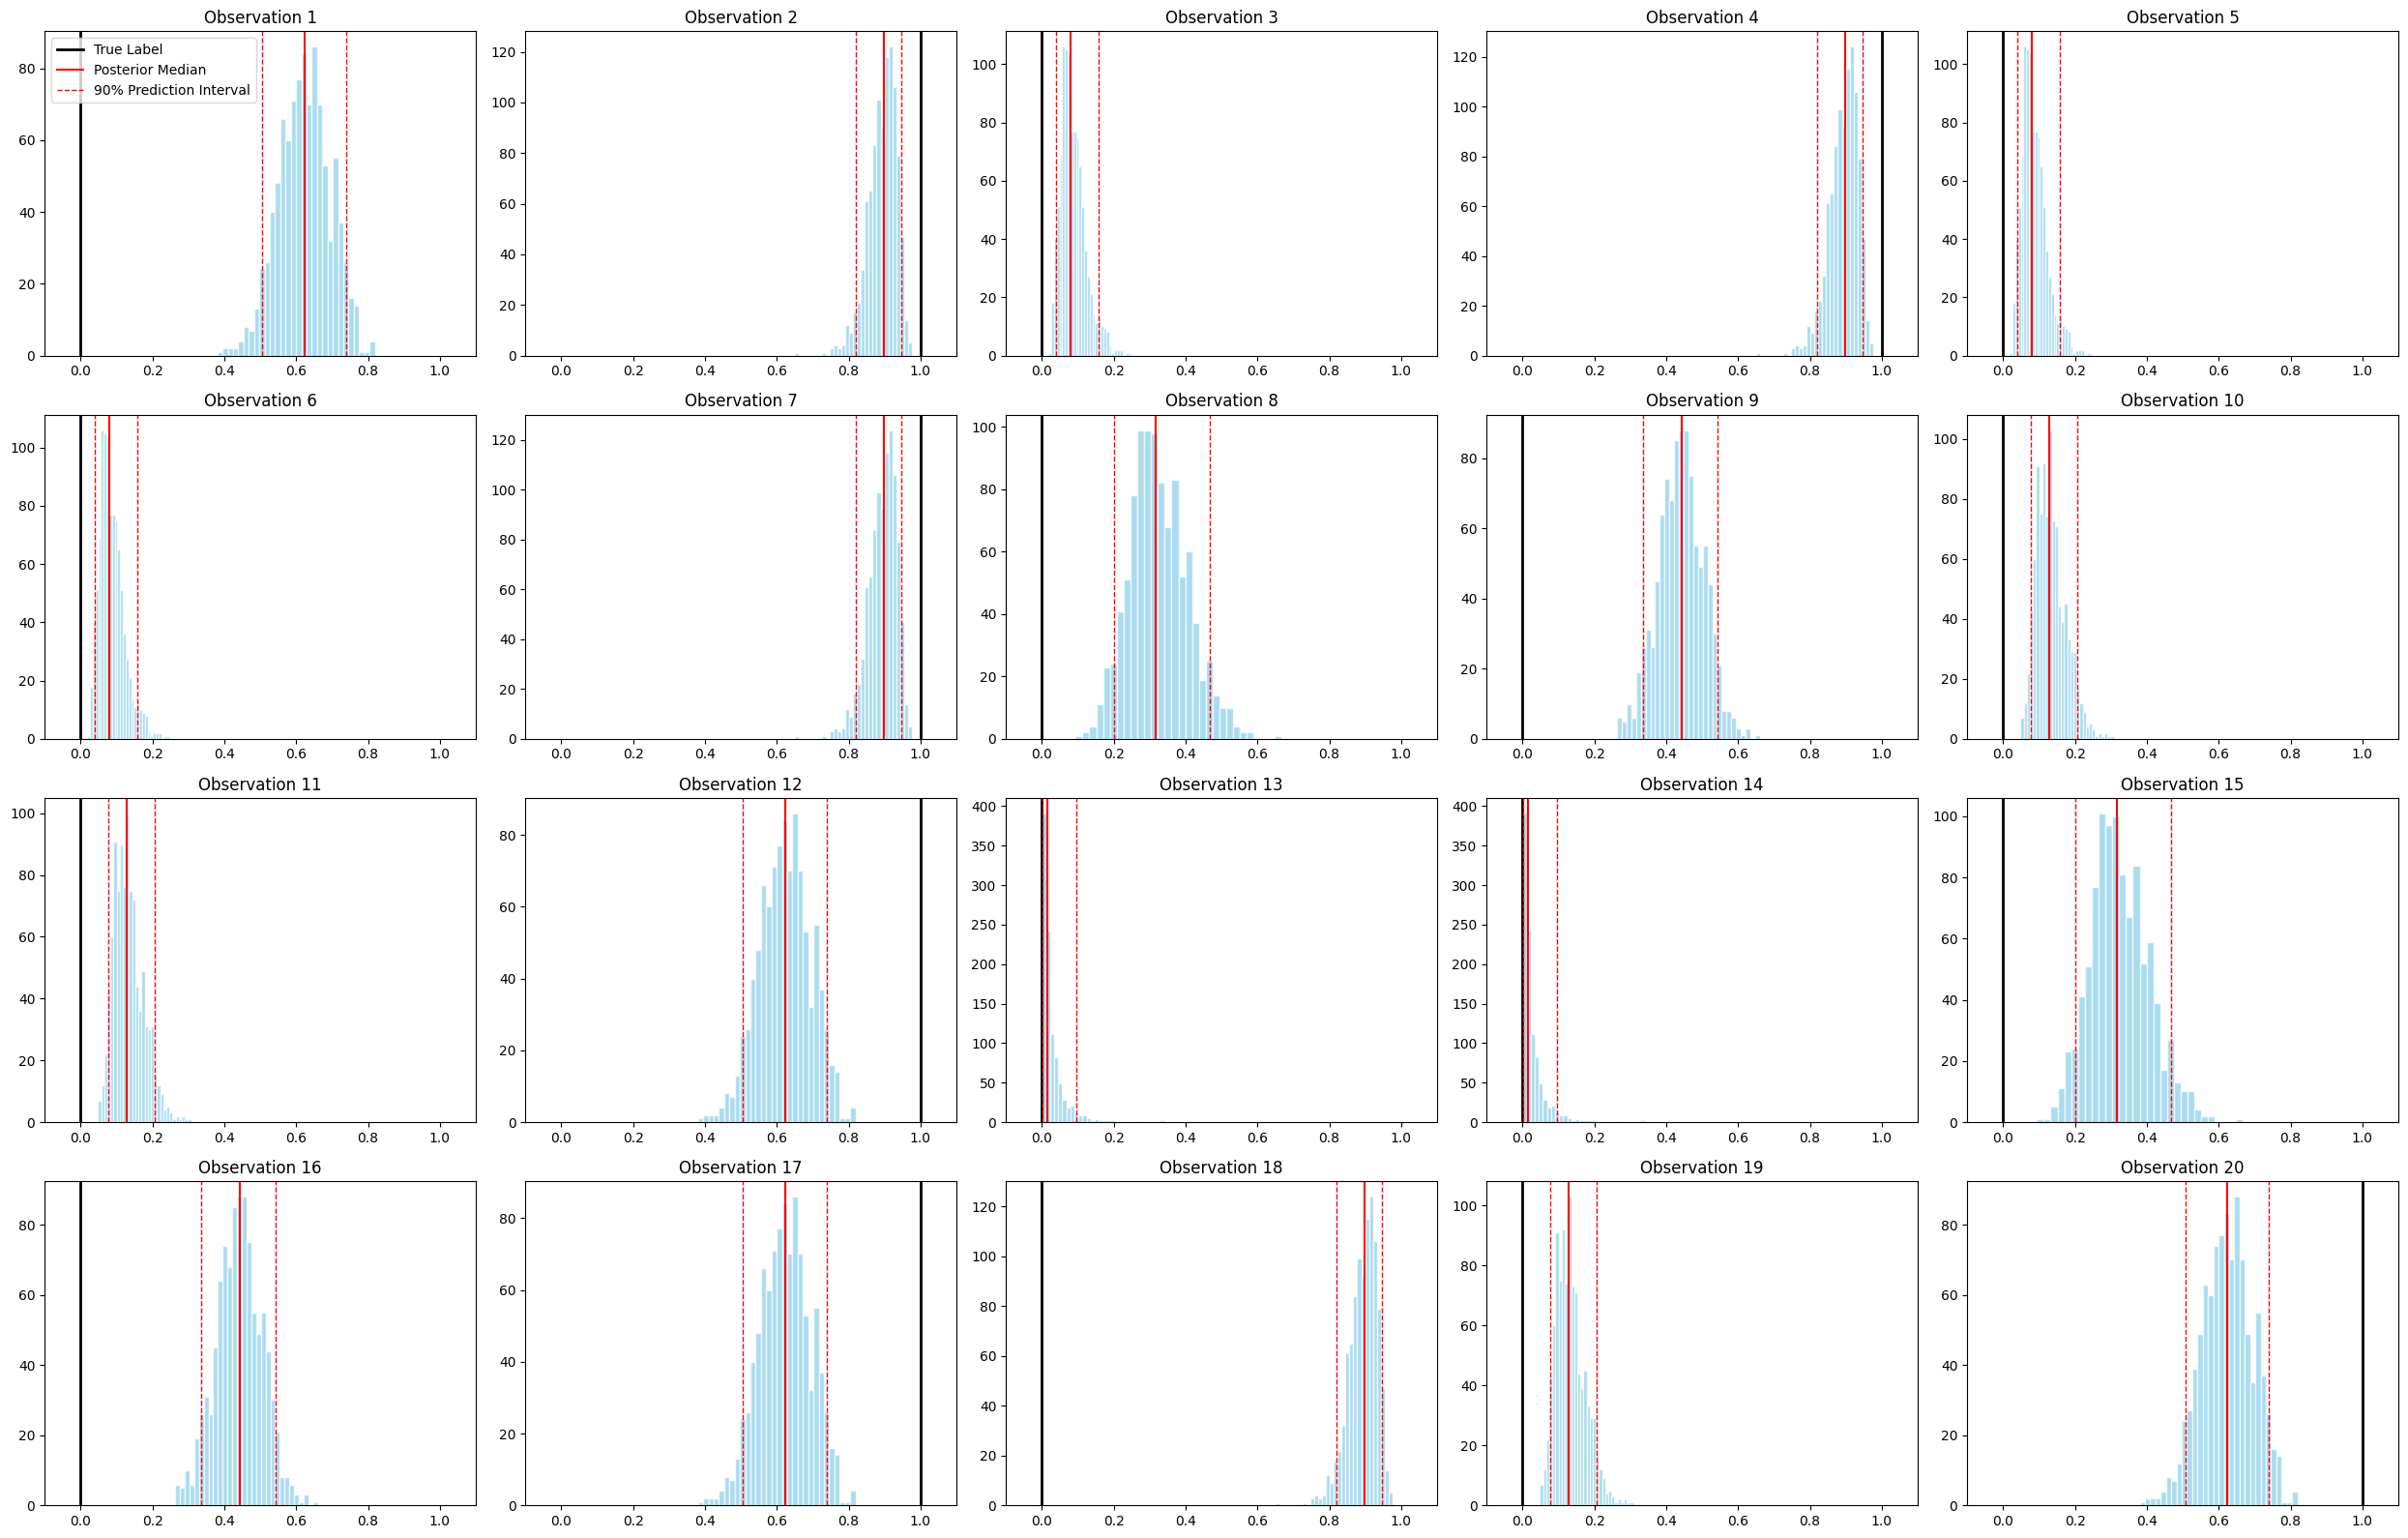

In [21]:
# True labels for the test set
true_labels = YX_const_test['Purchased']

# Calculate posterior median and the 90% prediction interval for each observation
posterior_medians = np.median(predictions, axis=0)
lower_bounds = np.percentile(predictions, 5, axis=0)
upper_bounds = np.percentile(predictions, 95, axis=0)

# Plot posterior distributions for the first 20 observations
fig, axes = plt.subplots(4, 5, figsize=(25, 16))
for i in range(20):
    ax = axes[i // 5, i % 5]
    # Histogram of simulated probabilities for observation i
    ax.hist(predictions[:, i], bins=30, color='skyblue', edgecolor='white', alpha=0.7)
    
    # Add the true label as a thick black line
    true_label_position = 0 if true_labels.iloc[i] == 0 else 1
    ax.axvline(x=true_label_position, color='black', linewidth=2, label='True Label' if i == 0 else "")
    
    # Add posterior median as a vertical line
    ax.axvline(x=posterior_medians[i], color='red', linestyle='-', label='Posterior Median' if i == 0 else "")
    
    # Mark 90% prediction interval with red lines
    ax.axvline(x=lower_bounds[i], color='red', linestyle='--', linewidth=1, label='90% Prediction Interval' if i == 0 else "")
    ax.axvline(x=upper_bounds[i], color='red', linestyle='--', linewidth=1)
    
    ax.set_xlim(-0.1, 1.1)
    ax.set_title(f'Observation {i+1}')
    if i == 0:  # Add legend only to the first subplot
        ax.legend()

plt.tight_layout()
plt.show()

Although some cases show wider uncertainty or mismatch, for most observations, the true lables align well with the predicted posterior distributions.

#### iv. Simulate predicted classes 

In [22]:
# Simulate classes (1s and 0s) for the test set
simulated_outcomes = (predictions >= 0.5).astype(int)  # Threshold for classification

# Verify the shape of simulated outcomes
print(f"Simulated Outcomes Shape: {simulated_outcomes.shape}")

Simulated Outcomes Shape: (1000, 100)


#### v. calculate generalization error

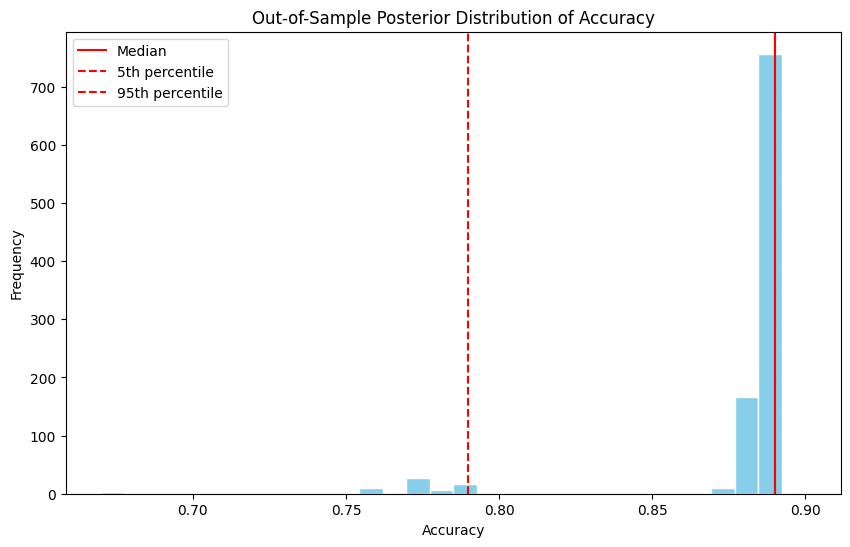

Median Accuracy: 0.8900
5th Percentile Accuracy: 0.7900
95th Percentile Accuracy: 0.8900


In [23]:
from sklearn.metrics import accuracy_score

# Calculate accuracy for each simulation
accuracies = []
for i in range(n_simulations):
    accuracy = accuracy_score(YX_const_test['Purchased'], simulated_outcomes[i])
    accuracies.append(accuracy)

# Plot the histogram of accuracies
plt.figure(figsize=(10, 6))
plt.hist(accuracies, bins=30, color='skyblue', edgecolor='white')
plt.axvline(x=np.median(accuracies), color='red', label='Median')
plt.axvline(x=np.percentile(accuracies, 5), color='red', linestyle='--', label='5th percentile')
plt.axvline(x=np.percentile(accuracies, 95), color='red', linestyle='--', label='95th percentile')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.title('Out-of-Sample Posterior Distribution of Accuracy')
plt.legend()
plt.show()

# Print summary statistics
print(f"Median Accuracy: {np.median(accuracies):.4f}")
print(f"5th Percentile Accuracy: {np.percentile(accuracies, 5):.4f}")
print(f"95th Percentile Accuracy: {np.percentile(accuracies, 95):.4f}")

1. **Histogram Shape** 
- The distribution of accuracies is heavily skewed clustering at 0.89, with a small number below 0.79.
        - This indicates the model performs consistently well in most cases.

2. Why It's Not nomralized:
- Since predictions are binary (0,1), accuracy may naturally clusters.
- Reduced variabilities in coefficients can lead to similar outcomes across simulations.
- Some predictors (like age or income) might dominate, limiting the range of outcomes. 